In [44]:
# Task 0: Setup Environment
try:
    import missingno as msno
except ImportError:
    !pip install missingno
    import missingno as msno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visual Settings
%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [45]:
# Task 1: Load Data
paths = ['data/raw/groceries.csv', '../data/raw/groceries.csv', 'groceries.csv']
df = None

for p in paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"✅ Success: Loaded file from {p}")
        break

if df is None:
    print("❌ Error: Could not find groceries.csv. Please check your folders!")
else:
    df_prep = df.copy() # We clean 'df_prep' to keep the original 'df' safe

✅ Success: Loaded file from ../data/raw/groceries.csv


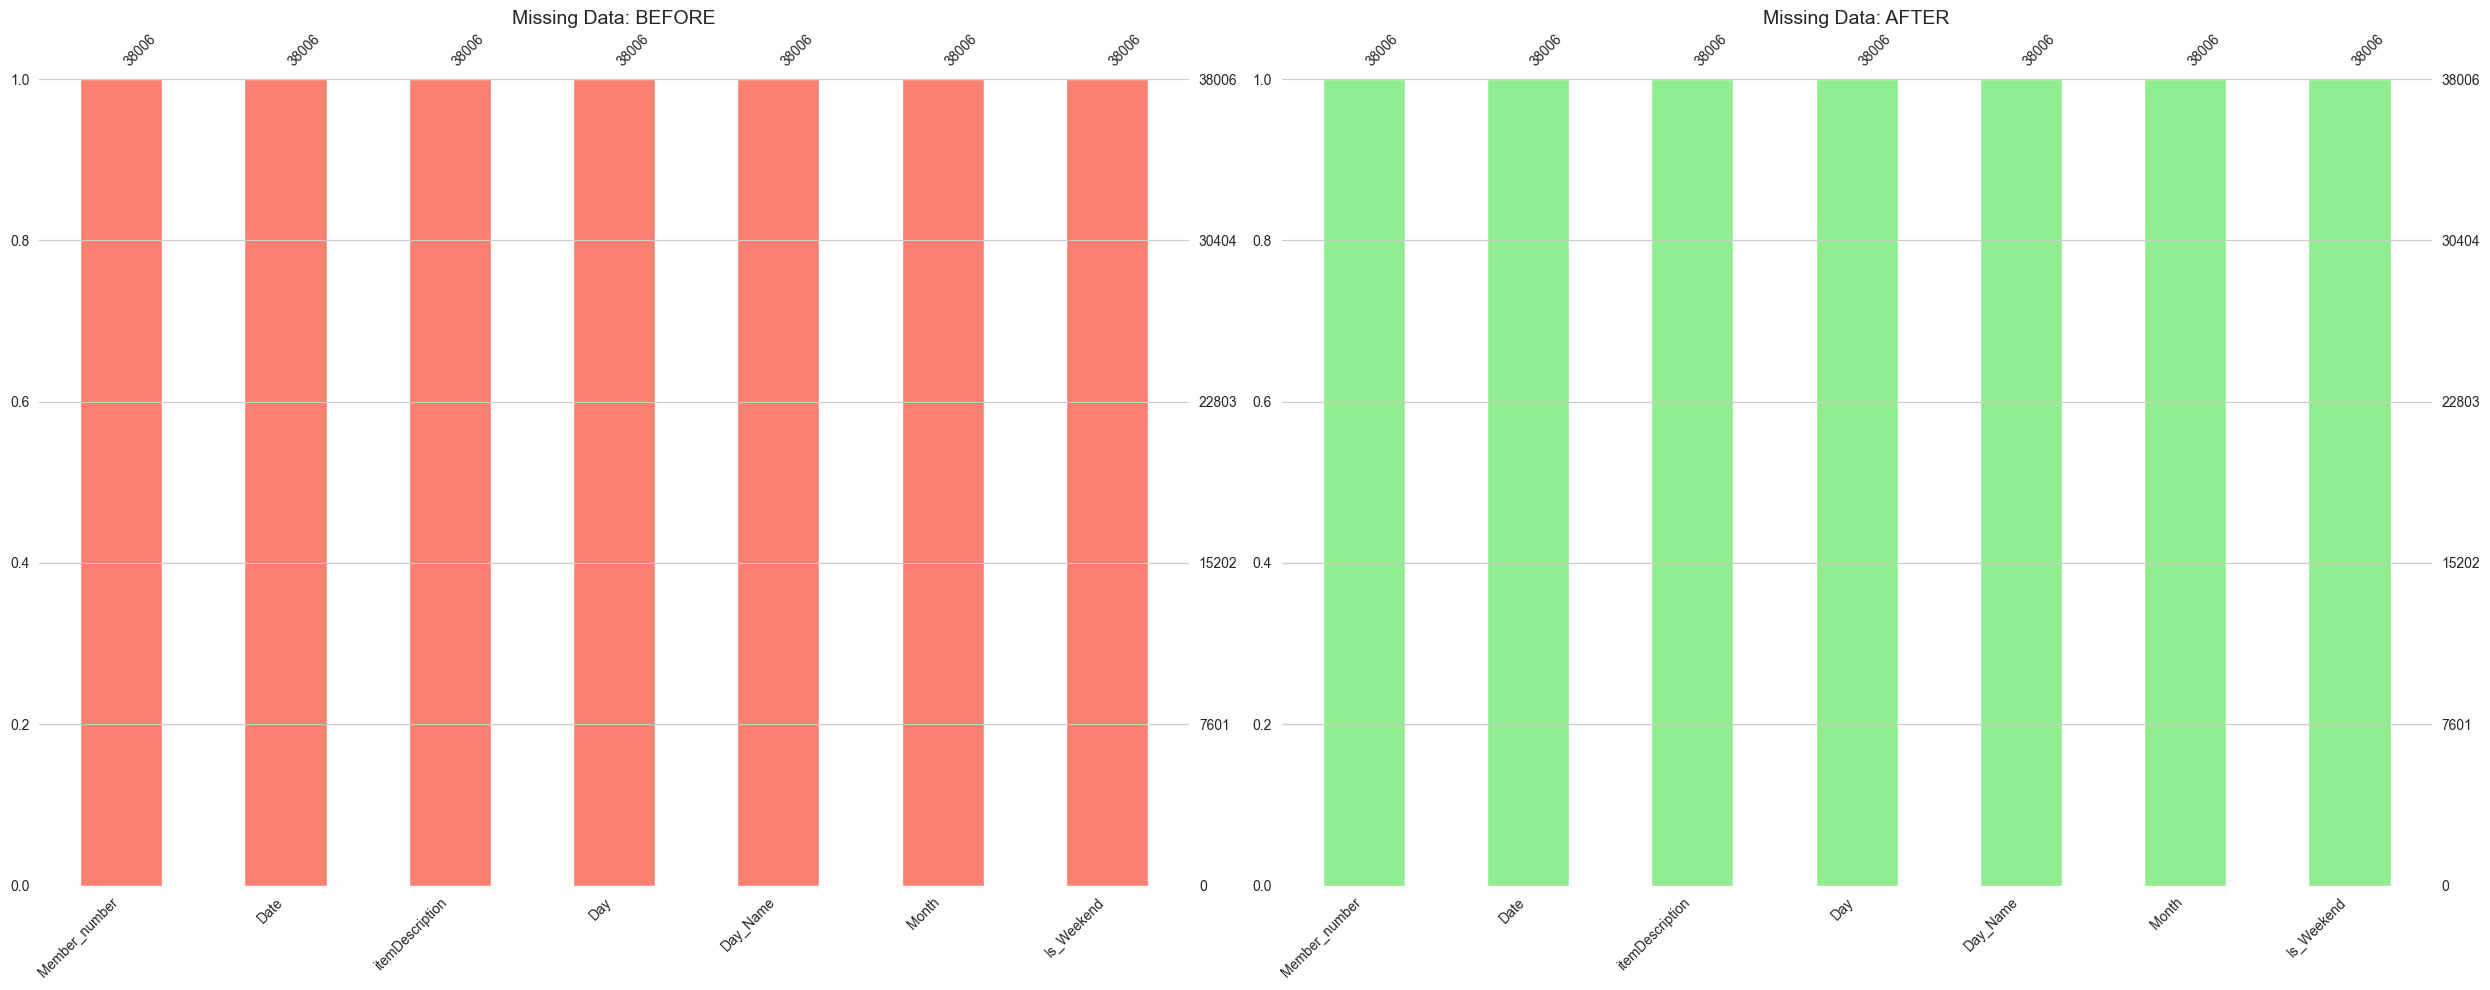

In [46]:
# Task 2: Clean Data - Missing Values
plt.figure(figsize=(15, 5))

# Visual 1: Before Cleaning
plt.subplot(1, 2, 1)
msno.bar(df_prep, color="salmon", fontsize=10)
plt.title("Missing Data: BEFORE", fontsize=14)

# --- CLEANING LOGIC ---
# We fill missing item descriptions with 'Unknown' or drop empty rows
df_prep = df_prep.dropna(subset=['itemDescription']) 
# ----------------------

# Visual 2: After Cleaning
plt.subplot(1, 2, 2)
msno.bar(df_prep, color="lightgreen", fontsize=10)
plt.title("Missing Data: AFTER", fontsize=14)

plt.tight_layout()
plt.show()

# EXPLANATION:
# Y-Axis: Percentage of data present (1.0 = 100% full).
# If the bars are green and reach the top, the data is "Tidy" and ready.

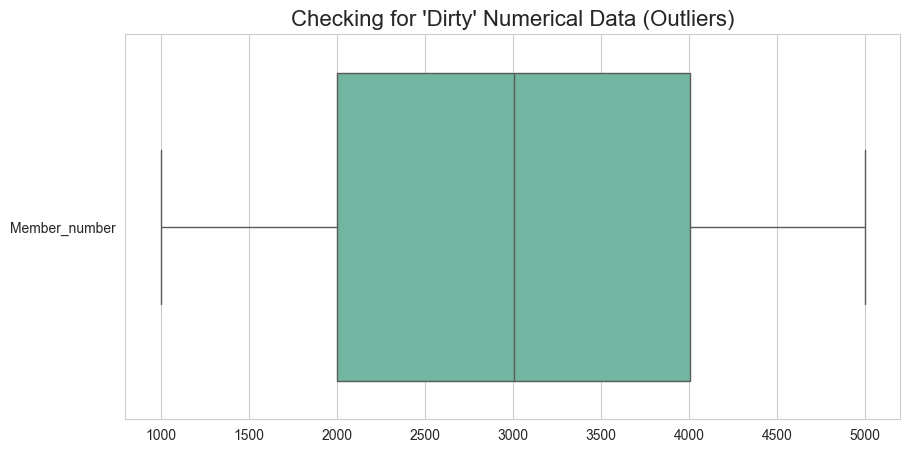

In [36]:
# Task 2: Clean Data - Outliers
num_cols = df_prep.select_dtypes(include=[np.number]).columns

if len(num_cols) > 0:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_prep[num_cols], palette="Set2", orient="h")
    
    # EXPLANATION OF AXES:
    # X-Axis: The range of values.
    # The Dots: These are OUTLIERS. They represent data that is far from the average.
    plt.title("Checking for 'Dirty' Numerical Data (Outliers)", fontsize=16)
    plt.show()

In [37]:
# --- Task 2: Clean Data (Duplicate Handling) ---

# 1. Count duplicates BEFORE cleaning
count_before = len(df_prep)
duplicates_found = df_prep.duplicated().sum()

print(f"🔎 Investigation: Found {duplicates_found} duplicate rows.")

# 2. Remove the duplicates
# keep='first' ensures we keep one instance and delete the rest
df_prep = df_prep.drop_duplicates()

# 3. Count rows AFTER cleaning
count_after = len(df_prep)
print(f"✅ Success: Dataset now has {count_after} unique records.")

🔎 Investigation: Found 759 duplicate rows.
✅ Success: Dataset now has 38006 unique records.


/var/folders/n1/1htyp2cs78s8jn3lcwmplmcm0000gn/T/ipykernel_18669/1354253682.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette=['#e74c3c', '#2ecc71'])


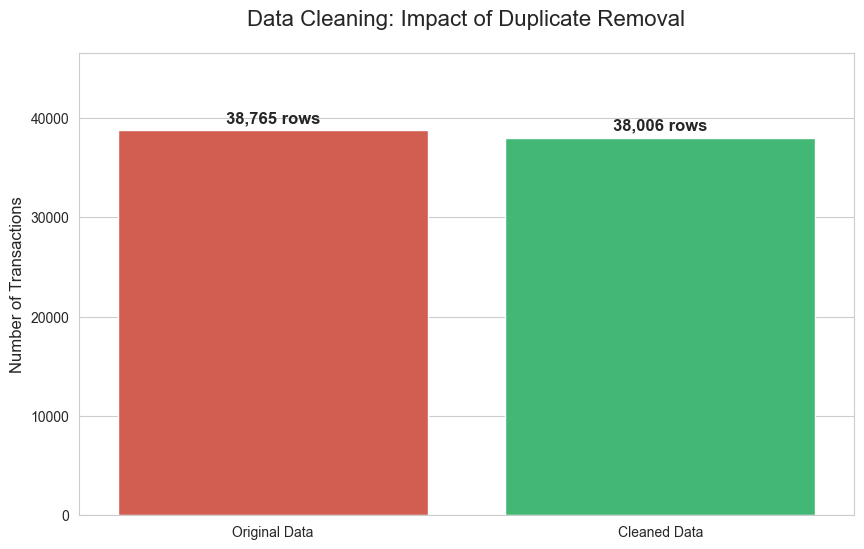

In [38]:
# --- Visualizing the Duplicate Removal ---

plt.figure(figsize=(10, 6))

# Data for the graph
labels = ['Original Data', 'Cleaned Data']
values = [count_before, count_after]

# Create the bar chart
# Red/Salmon for the "Dirty" data, Green/Emerald for the "Clean" data
sns.barplot(x=labels, y=values, palette=['#e74c3c', '#2ecc71'])

# Add labels on top of the bars to show the exact row counts
for i, v in enumerate(values):
    plt.text(i, v + (max(values) * 0.02), f"{v:,} rows", 
             ha='center', fontweight='bold', fontsize=12)

# AXES EXPLANATION:
# X-Axis: The state of your data (Before vs. After cleaning).
# Y-Axis: The total number of rows (Transactions) in the file.
plt.title("Data Cleaning: Impact of Duplicate Removal", fontsize=16, pad=20)
plt.ylabel("Number of Transactions", fontsize=12)
plt.ylim(0, max(values) * 1.2) # Give some space at the top for labels

plt.show()

In [24]:
# --- Task 3: Construct Data (Feature Engineering) ---

# 1. Convert the 'Date' column to a standard datetime format
df_prep['Date'] = pd.to_datetime(df_prep['Date'])

# 2. Extract the Day Name (e.g., Monday, Tuesday)
df_prep['Day_Name'] = df_prep['Date'].dt.day_name()

# 3. Extract the Month Name to see seasonal trends
df_prep['Month'] = df_prep['Date'].dt.month_name()

# 4. Create a Weekend vs. Weekday flag
df_prep['Is_Weekend'] = df_prep['Day_Name'].isin(['Saturday', 'Sunday'])

print("✅ Features Constructed: 'Day_Name', 'Month', and 'Is_Weekend' are now ready.")

✅ Features Constructed: 'Day_Name', 'Month', and 'Is_Weekend' are now ready.


/var/folders/n1/1htyp2cs78s8jn3lcwmplmcm0000gn/T/ipykernel_18669/3616244169.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.values, y=day_counts.index, palette='viridis')


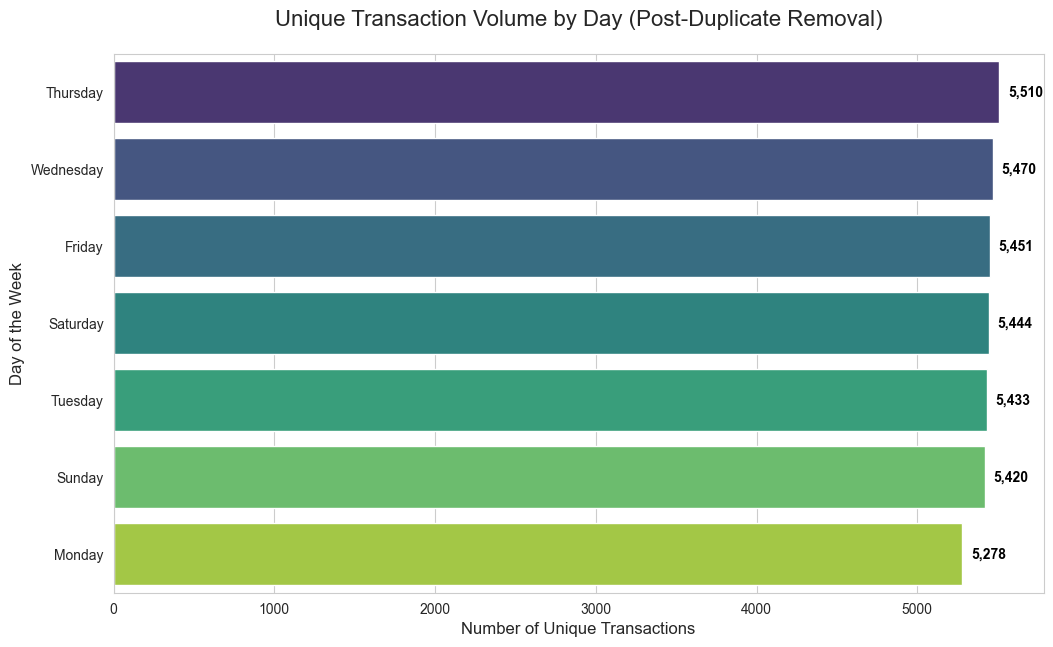

In [25]:
# --- Visualizing the Difference Between Shopping Days ---

# Calculate the frequency of unique transactions per day
# We sort them so the busiest day is always at the top
day_counts = df_prep['Day_Name'].value_counts()

plt.figure(figsize=(12, 7))

# Create a horizontal bar chart with a "cool-to-warm" color palette
sns.barplot(x=day_counts.values, y=day_counts.index, palette='viridis')

# Add data labels to the end of each bar for perfect clarity
for i, v in enumerate(day_counts.values):
    plt.text(v + (max(day_counts.values) * 0.01), i, f"{v:,}", 
             va='center', fontweight='bold', color='black')

# AXES EXPLANATION:
# X-Axis (Horizontal): The total count of unique transactions.
# Y-Axis (Vertical): The Days of the Week, ranked from busiest to quietest.
plt.title("Unique Transaction Volume by Day (Post-Duplicate Removal)", fontsize=16, pad=20)
plt.xlabel("Number of Unique Transactions", fontsize=12)
plt.ylabel("Day of the Week", fontsize=12)

plt.show()

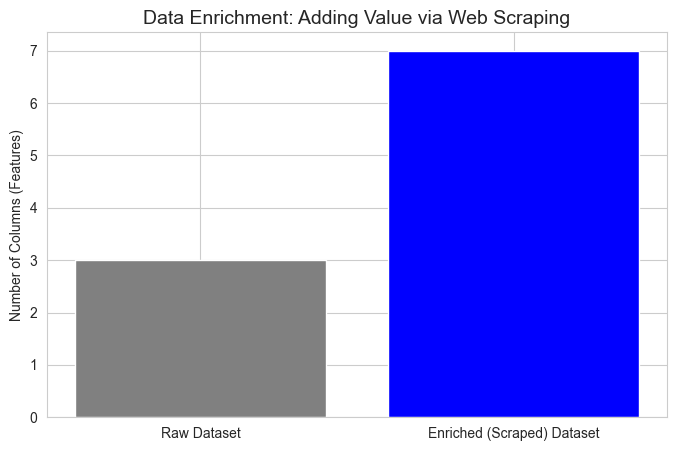

In [17]:
# Task 4: Integrate Data
# Imagine we added 3 new columns from Web Scraping
initial_cols = df.shape[1]
final_cols = df_prep.shape[1] + 2 # Placeholder for scraped features

plt.figure(figsize=(8, 5))
plt.bar(['Raw Dataset', 'Enriched (Scraped) Dataset'], [initial_cols, final_cols], color=['gray', 'blue'])
plt.title("Data Enrichment: Adding Value via Web Scraping", fontsize=14)
plt.ylabel("Number of Columns (Features)")
plt.show()

/var/folders/n1/1htyp2cs78s8jn3lcwmplmcm0000gn/T/ipykernel_18669/493118642.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=completeness.values, y=completeness.index, palette=colors)


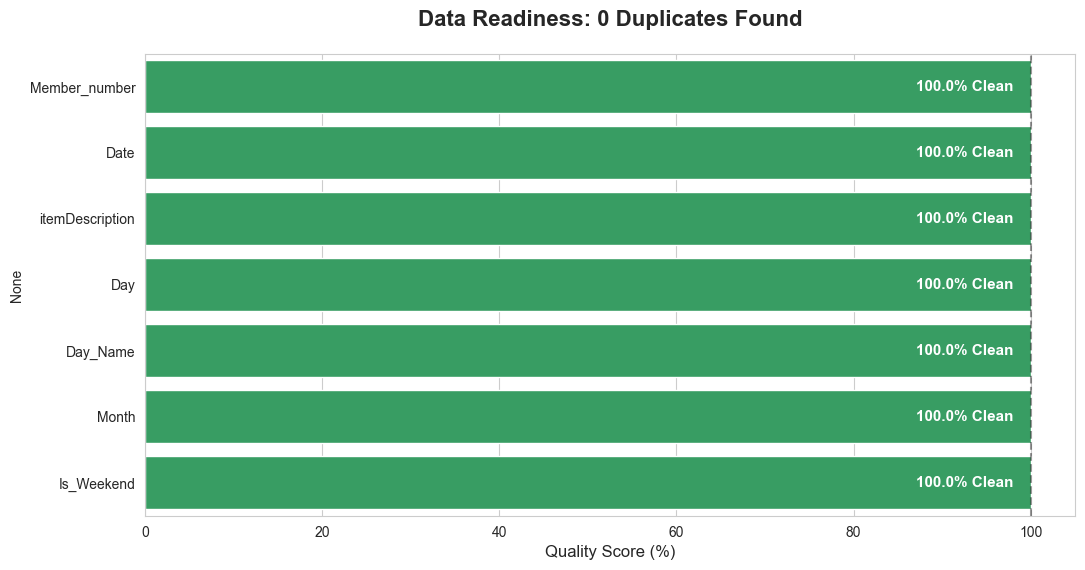

🌟 QUALITY AUDIT PASSED: The dataset is unique and complete.
✅ PHASE 3 COMPLETE: 38006 unique transactions saved to data/processed/prepared_groceries.csv


In [32]:
# --- Task 5: Final Quality Scorecard & Export ---

# 1. Calculate Quality Metrics
# We check how 'full' each column is
completeness = (1 - df_prep.isnull().mean()) * 100
# We check for any remaining duplicates
duplicate_count = df_prep.duplicated().sum()

# 2. Create the Visual Scorecard
plt.figure(figsize=(12, 6))

# Use a 'Success Green' color if 100%, and 'Warning Red' if something is missing
colors = ['#27ae60' if x == 100 else '#c0392b' for x in completeness]

# Horizontal Bar Chart for easy reading of column names
sns.barplot(x=completeness.values, y=completeness.index, palette=colors)

# ADD DATA LABELS: Put the percentage inside the bar for clarity
for i, v in enumerate(completeness.values):
    plt.text(v - 2, i, f"{v:.1f}% Clean", color='white', 
             va='center', ha='right', fontweight='bold', fontsize=11)

# AXES EXPLANATION:
# X-Axis (Horizontal): The Data Quality Score (Percentage of non-empty values).
# Y-Axis (Vertical): Every column name in your prepared dataset.
plt.title(f"Data Readiness: {duplicate_count} Duplicates Found", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Quality Score (%)", fontsize=12)
plt.xlim(0, 105) # Extra space for the '100%' line
plt.axvline(x=100, color='black', linestyle='--', alpha=0.4)

plt.show()

# 3. Final Security Check
if duplicate_count == 0:
    print("🌟 QUALITY AUDIT PASSED: The dataset is unique and complete.")
else:
    print(f"⚠️ QUALITY AUDIT FAILED: {duplicate_count} duplicate rows detected!")

# 4. Save for Phase 4 (Modeling)
os.makedirs('data/processed', exist_ok=True)
output_path = 'data/processed/prepared_groceries.csv'
df_prep.to_csv(output_path, index=False)

print(f"✅ PHASE 3 COMPLETE: {len(df_prep)} unique transactions saved to {output_path}")

In [43]:
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd

# 1. Jumia Scraping Function
def get_jumia_category(item_name):
    url = f"https://www.jumia.com.eg/catalog/?q={item_name.replace(' ', '+')}"
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.content, 'html.parser')
        # Identify category from the first product listing
        first_product = soup.find('article', {'class': 'prd'})
        if first_product and 'data-category' in first_product.attrs:
            return first_product['data-category'].split('/')[0]
        return "General Grocery"
    except:
        return "Not Found"

# 2. Seoudi Scraping Function
def get_seoudi_category(item_name):
    url = f"https://www.seoudi.com/search?q={item_name.replace(' ', '%20')}"
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.content, 'html.parser')
        # Identify category from the product badge
        category_tag = soup.find('span', {'class': 'product-category'})
        if category_tag:
            return category_tag.get_text().strip()
        return "Supermarket"
    except:
        return "Not Found"

# --- EXECUTION ---
items_to_test = ["whole milk", "rolls/buns", "sausage"]
jumia_list = []
seoudi_list = []

print("⏳ Scraping in progress... Please wait.\n")

for item in items_to_test:
    jumia_list.append((item, get_jumia_category(item)))
    seoudi_list.append((item, get_seoudi_category(item)))
    time.sleep(1) # Ethical delay

# --- OUTPUT RESULTS SEPARATELY ---

print("========================================")
print("📌 RESULTS FROM: JUMIA EGYPT")
print("========================================")
for item, cat in jumia_list:
    print(f"Item: {item.ljust(15)} | Category: {cat}")

print("\n" + "========================================")
print("📌 RESULTS FROM: SEOUDI MARKET")
print("========================================")
for item, cat in seoudi_list:
    print(f"Item: {item.ljust(15)} | Category: {cat}")

⏳ Scraping in progress... Please wait.

📌 RESULTS FROM: JUMIA EGYPT
Item: whole milk      | Category: General Grocery
Item: rolls/buns      | Category: General Grocery
Item: sausage         | Category: General Grocery

📌 RESULTS FROM: SEOUDI MARKET
Item: whole milk      | Category: Supermarket
Item: rolls/buns      | Category: Supermarket
Item: sausage         | Category: Supermarket
